In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [2]:
#COLLECTION AND CLEANING OF DATA

In [3]:
# Dataset 1
df_dropout = pd.read_csv("student_academic_dropouts.csv", sep=";")

# Dataset 2
df_career = pd.read_csv("education_career_success.csv")

In [4]:
df_dropout.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [5]:
df_career.columns

Index(['Student_ID', 'Age', 'Gender', 'High_School_GPA', 'SAT_Score',
       'University_GPA', 'Field_of_Study', 'Internships_Completed',
       'Projects_Completed', 'Certifications', 'Soft_Skills_Score',
       'Networking_Score', 'Job_Offers', 'Starting_Salary',
       'Career_Satisfaction', 'Years_to_Promotion', 'Current_Job_Level',
       'Work_Life_Balance', 'Entrepreneurship'],
      dtype='object')

In [6]:
df_dropout.head(2)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate


In [7]:
df_career.head(2)

,Student_ID,Age,Gender,High_School_GPA,SAT_Score,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
0,S001,22,Male,3.8,1450,3.6,Computer Science,3,7,2,8,7,3,85000,8,2,Mid,7,No
1,S002,24,Female,3.6,1380,3.4,Business,2,5,3,7,6,2,65000,7,3,Mid,6,No


In [8]:
#Cleaning data
for name, df in [("Dropout dataset", df_dropout), ("Career dataset", df_career)]:
    print(f"\n{name}\n")
    print("Shape:", df.shape)
    print("\nMissing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nData types:\n", df.dtypes.value_counts())


Dropout dataset

Shape: (4424, 37)

Missing values per column:
 Series([], dtype: int64)

Duplicate rows: 0

Data types:
 int64      29
float64     7
object      1
dtype: int64

Career dataset

Shape: (400, 19)

Missing values per column:
 Series([], dtype: int64)

Duplicate rows: 0

Data types:
 int64      12
object      5
float64     2
dtype: int64


In [9]:
#Dataset 1 copy after cleaning applied
df1 = df_dropout.copy()
df1["At_Risk"] = df1["Target"].apply(lambda x: 1 if x.strip().lower() == "dropout" else 0)
df1 = df1.drop(columns=["Target"]) #Replacing text data

print(df1["At_Risk"].value_counts(normalize=True))

0    0.678797
1    0.321203
Name: At_Risk, dtype: float64


In [10]:
# Dataset 2 copy after cleaning applied
df2 = df_career.copy()
df2 = df2.drop(columns=["Student_ID", "Entrepreneurship"])  # ID has no signal, Entrepreneurship has zero variance

cat_cols = ["Gender", "Field_of_Study", "Current_Job_Level"]  # Replacing text data
for col in cat_cols:
    df2[col] = LabelEncoder().fit_transform(df2[col].astype(str))

median_val = df2["Career_Satisfaction"].median()
df2["Career_Success"] = (df2["Career_Satisfaction"] >= median_val).astype(int)
df2 = df2.drop(columns=["Career_Satisfaction"])
print(df2["Career_Success"].value_counts(normalize=True))

1    0.545
0    0.455
Name: Career_Success, dtype: float64


In [11]:
#DATA EXPLORATION AND VISUALISATION

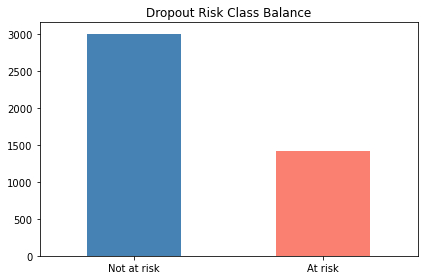

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

#Dataset 1
fig, ax = plt.subplots(figsize=(6, 4))
df1["At_Risk"].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "salmon"])
ax.set_title("Dropout Risk Class Balance")
ax.set_xticklabels(["Not at risk", "At risk"], rotation=0)
plt.tight_layout()
plt.savefig("dropout_class_balance.png", dpi=150)
plt.show()

Displaced
0    0.376376
1    0.275763
Name: At_Risk, dtype: float64


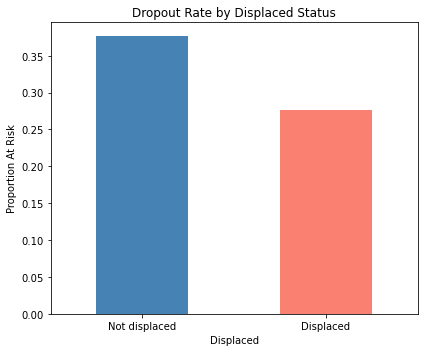

In [13]:
# At-risk rate by displaced status
#displaced are likely to be doing their classes online, which KeyPath would see value in
displaced_rate = df1.groupby("Displaced")["At_Risk"].mean()
print(displaced_rate)

fig, ax = plt.subplots(figsize=(6, 5))
displaced_rate.plot(kind="bar", ax=ax, color=["steelblue", "salmon"])
ax.set_title("Dropout Rate by Displaced Status")
ax.set_xlabel("Displaced")
ax.set_ylabel("Proportion At Risk")
ax.set_xticklabels(["Not displaced", "Displaced"], rotation=0)
plt.tight_layout()
plt.savefig("dropout_rate_by_displaced.png", dpi=150)
plt.show()

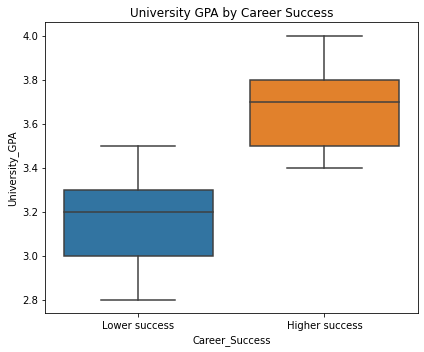

In [14]:
#Dataset 2 Visualisations
#Correlation betweem success and GPA
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df2, x="Career_Success", y="University_GPA", ax=ax)
ax.set_title("University GPA by Career Success")
ax.set_xticklabels(["Lower success", "Higher success"])
plt.tight_layout()
plt.savefig("gpa_vs_career_success.png", dpi=150)
plt.show()

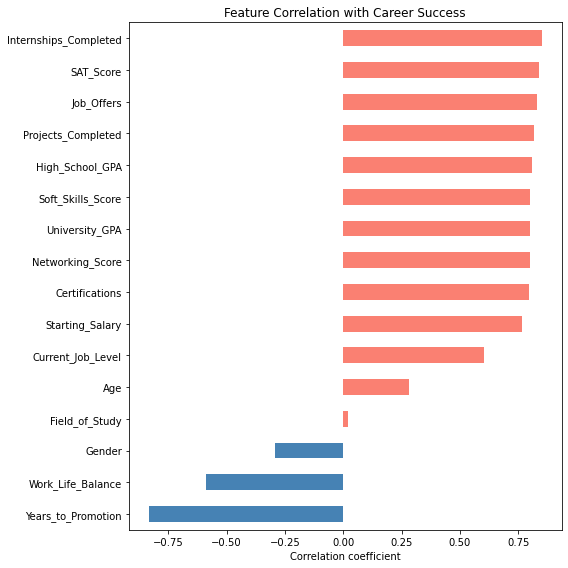

In [15]:
#Feature correlation with Career Success

correlations2 = df2.corr()["Career_Success"].drop("Career_Success").sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
correlations2.plot(kind="barh", ax=ax, color=correlations2.apply(lambda x: "salmon" if x > 0 else "steelblue"))
ax.set_title("Feature Correlation with Career Success")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.savefig("correlation_with_career_success.png", dpi=150)
plt.show()

In [16]:
#MODELLING

In [17]:
#Dataset 1 using Random Forest machine algorithm (New Model)

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, roc_auc_score

# Prepare features and target (df1 is already cleaned/encoded from earlier steps)
X = df1.drop(columns=["At_Risk"])
y = df1["At_Risk"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Build and train the Random Forest
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

# Predict on the test set
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]  # probability of being "at risk"

# Evaluate
print(classification_report(y_test, rf_pred, target_names=["Not at risk", "At risk"]))
print("F1:", f1_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))

              precision    recall  f1-score   support

 Not at risk       0.88      0.96      0.92       751
     At risk       0.90      0.74      0.81       355

    accuracy                           0.89      1106
   macro avg       0.89      0.85      0.87      1106
weighted avg       0.89      0.89      0.89      1106

F1: 0.8093023255813954
Precision: 0.9
Recall: 0.7352112676056338
ROC-AUC: 0.9366666041522101


In [18]:
from sklearn.metrics import precision_recall_curve

# By default, predict() uses a 0.5 probability threshold.
# Comparing different thresholds

thresholds_to_try = [0.5, 0.4, 0.3, 0.2]

for t in thresholds_to_try:
    adjusted_pred = (rf_proba >= t).astype(int)
    print(f"\n--- Threshold = {t} ---")
    print("Precision:", precision_score(y_test, adjusted_pred))
    print("Recall:", recall_score(y_test, adjusted_pred))
    print("F1:", f1_score(y_test, adjusted_pred))

# Deciding on 0.4 as it has significantly greater recall than 0.5, but not much lower for precision compared to 0.5.


--- Threshold = 0.5 ---
Precision: 0.9003436426116839
Recall: 0.7380281690140845
F1: 0.8111455108359134

--- Threshold = 0.4 ---
Precision: 0.8284883720930233
Recall: 0.8028169014084507
F1: 0.8154506437768241

--- Threshold = 0.3 ---
Precision: 0.7530266343825666
Recall: 0.8760563380281691
F1: 0.8098958333333334

--- Threshold = 0.2 ---
Precision: 0.6310679611650486
Recall: 0.9154929577464789
F1: 0.7471264367816093


In [19]:
# Final predictions using decided threshold
final_threshold = 0.4
rf_pred_final = (rf_proba >= final_threshold).astype(int)

print("=== Final Random Forest Results (threshold = 0.4) ===")
print(classification_report(y_test, rf_pred_final, target_names=["Not at risk", "At risk"]))
print("F1:", f1_score(y_test, rf_pred_final))
print("Precision:", precision_score(y_test, rf_pred_final))
print("Recall:", recall_score(y_test, rf_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))  # ROC-AUC doesn't depend on threshold

=== Final Random Forest Results (threshold = 0.4) ===
              precision    recall  f1-score   support

 Not at risk       0.91      0.92      0.91       751
     At risk       0.83      0.80      0.82       355

    accuracy                           0.88      1106
   macro avg       0.87      0.86      0.87      1106
weighted avg       0.88      0.88      0.88      1106

F1: 0.8154506437768241
Precision: 0.8284883720930233
Recall: 0.8028169014084507
ROC-AUC: 0.9366666041522101


Top 10 features driving dropout risk:
Curricular units 2nd sem (approved)       0.160820
Curricular units 2nd sem (grade)          0.108436
Curricular units 1st sem (approved)       0.102707
Curricular units 1st sem (grade)          0.062669
Tuition fees up to date                   0.057318
Age at enrollment                         0.039715
Admission grade                           0.038201
Curricular units 2nd sem (evaluations)    0.035373
Previous qualification (grade)            0.035326
Course                                    0.029730
dtype: float64


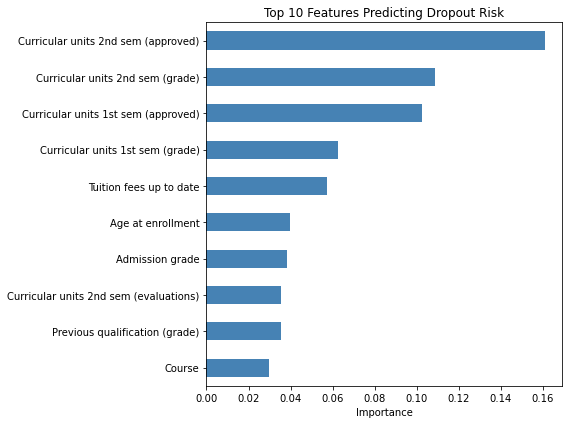

In [20]:
#Finding top 10 features from the dataset that drived dropout risk prediction
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("Top 10 features driving dropout risk:")
print(importances.head(10))

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(10).plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("Top 10 Features Predicting Dropout Risk")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("section1_feature_importance.png", dpi=150)
plt.show()

In [21]:
#Dataset 2 using KNN (Model learnt in my previous uni classes)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Prepare features and target
X2 = df2.drop(columns=["Career_Success"])
y2 = df2["Career_Success"]

# Train/test split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=42, stratify=y2
)

# kNN is distance-based, so features MUST be scaled first
# (e.g. Starting_Salary in the tens of thousands would otherwise dominate
# a feature like Networking_Score on a 1-10 scale)
scaler = StandardScaler()
X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)

# Build and train kNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X2_train_scaled, y2_train)

# Predict
knn_pred = knn.predict(X2_test_scaled)
knn_proba = knn.predict_proba(X2_test_scaled)[:, 1]

# Evaluate
print(classification_report(y2_test, knn_pred, target_names=["Lower success", "Higher success"]))
print("F1:", f1_score(y2_test, knn_pred))
print("Precision:", precision_score(y2_test, knn_pred))
print("Recall:", recall_score(y2_test, knn_pred))
print("ROC-AUC:", roc_auc_score(y2_test, knn_proba))

                precision    recall  f1-score   support

 Lower success       0.96      1.00      0.98        46
Higher success       1.00      0.96      0.98        54

      accuracy                           0.98       100
     macro avg       0.98      0.98      0.98       100
  weighted avg       0.98      0.98      0.98       100

F1: 0.9811320754716981
Precision: 1.0
Recall: 0.9629629629629629
ROC-AUC: 1.0


Top 10 features driving career success (kNN):
Age                      0.020
Internships_Completed    0.004
Gender                   0.000
Field_of_Study           0.000
Current_Job_Level        0.000
Work_Life_Balance        0.000
SAT_Score               -0.004
Soft_Skills_Score       -0.004
Networking_Score        -0.004
Starting_Salary         -0.006
dtype: float64


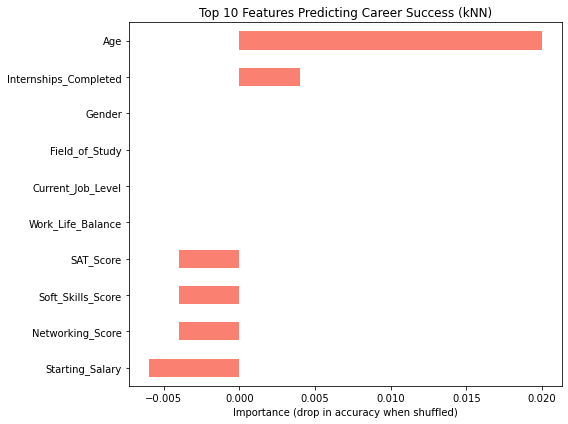

In [22]:
#Finding top 10 features from the dataset that drived dropout risk prediction
from sklearn.inspection import permutation_importance

perm = permutation_importance(knn, X2_test_scaled, y2_test, n_repeats=10, random_state=42)
knn_importances = pd.Series(perm.importances_mean, index=X2.columns).sort_values(ascending=False)

print("Top 10 features driving career success (kNN):")
print(knn_importances.head(10))

fig, ax = plt.subplots(figsize=(8, 6))
knn_importances.head(10).plot(kind="barh", ax=ax, color="salmon")
ax.invert_yaxis()
ax.set_title("Top 10 Features Predicting Career Success (kNN)")
ax.set_xlabel("Importance (drop in accuracy when shuffled)")
plt.tight_layout()
plt.savefig("section2_feature_importance.png", dpi=150)
plt.show()